# LOADING LIBRARIES

In [ ]:
from typing import Literal

import torch
import numpy as np
import torchvision
import pandas as pd
import torch.nn as nn
from pathlib import Path
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# LOADING DATASET

In [68]:
def load_imgs_as_tensor(imgs_parent_dir: str) -> torch.Tensor:
    imsge_files = list(sorted(
        Path(imgs_parent_dir).glob("*.png"),
        key=lambda filename: int(filename.name.rstrip(".png"))
    ))
    imgs = torch.empty(len(imsge_files), 256, 256, dtype=torch.uint8)
    for img_idx, image_file in enumerate(imsge_files):
        imgs[img_idx] = torchvision.io.decode_image(image_file)[0]
    return imgs

labels_df: pd.DataFrame = pd.read_csv('dataset/raw/y-train.csv', index_col=0).T.iloc[:800]
labeled_img_mask = labels_df.nunique(axis=1).gt(1).values
labels_df = labels_df.loc[labeled_img_mask]

x_train = (
    load_imgs_as_tensor("dataset/raw/x-train")
    [:800]
    [labeled_img_mask]
    .type(torch.float32)
    .reshape(-1, 1, 256,256)
)
x_test = (
    load_imgs_as_tensor("dataset/raw/x-test")
    .type(torch.float32)
    .reshape(-1, 1, 256,256)
)
y_train = (
    torch.from_numpy(
        labels_df
        .astype("float64")
        .values
    )
    .reshape(-1, 256,256)
)

## KEEP WITH THE ABOVE CODE
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train,
    y_train,
    test_size=0.02,
    random_state=0,
)
assert len(x_train) == len(y_train)
assert len(x_valid) == len(y_valid)
print(f"Number of training images {len(x_train)}")
print(f"Number of validation images {len(x_valid)}")

Number of training images 743
Number of validation images 16


In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Our dataset images shape is torch.Size([743, 1, 256, 256])
Our dataset labels shape is torch.Size([743, 256, 256])
sampole mean 2.7628631591796875


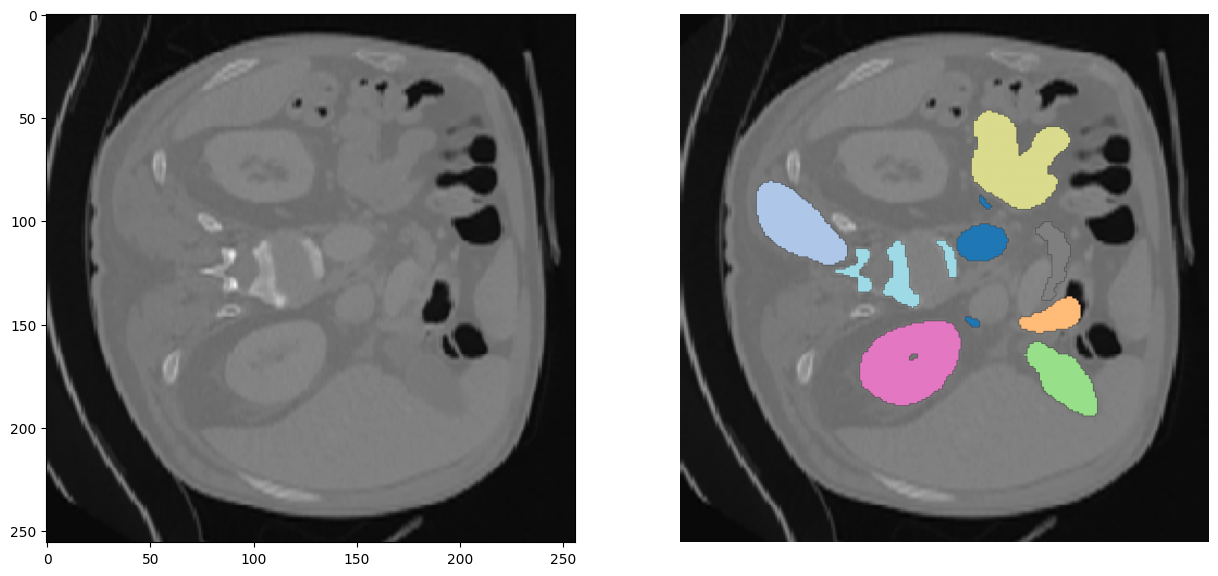

In [74]:
# Here is a function to display side by side a slide and a segmented mask
def plot_slice_seg(slice_image, *seg_masks):
    fig, axes = plt.subplots(1, 1 + len(seg_masks))
    fig = fig.set_size_inches(15, 15)
    axes[0].imshow(slice_image, cmap="gray")
    for seg_i, seg_mask in enumerate(seg_masks):
        axes[seg_i + 1].imshow(slice_image, cmap="gray")
        seg_masked = np.ma.masked_where(seg_mask.reshape((256,256)) == 0, (seg_mask.reshape((256,256))))
        axes[seg_i + 1].imshow(seg_masked, cmap="tab20")
    plt.axis("off")
    plt.show()

@torch.no_grad
def plt_pred(
        model: nn.Module,
        sample_idx: int,
        split: Literal["train", "val", "test"],
    ):
    x = {"train": x_train, "val": x_valid, "test": x_test}[split]
    image_test = x[sample_idx]
    label_test = model(image_test.unsqueeze(0).to(device))
    pred_test = torch.argmax(label_test, dim=1)
    if split in ("train", "val"):
        y = {"train": y_train, "val":y_valid}[split]
        plot_slice_seg(
            image_test.squeeze(),
            pred_test.squeeze().cpu().numpy(),
            y[sample_idx],
        )
    else:
        plot_slice_seg(
            image_test.squeeze(),
            pred_test.squeeze().cpu().numpy(),
        )


print(f"Our dataset images shape is {x_train.shape}")
print(f"Our dataset labels shape is {y_train.shape}")
SAMPLE_IDX = 600
print(f"sampole mean {y_train[SAMPLE_IDX].squeeze().mean()}")
plot_slice_seg(
    x_train[SAMPLE_IDX].squeeze(),
    y_train[SAMPLE_IDX].squeeze().to(dtype=torch.float32),
)

In [4]:
def standardize_dataset(dataset: np.ndarray | torch.Tensor):
    mean, std = dataset.mean(), dataset.std()
    return (dataset - mean) / (std + 1e-8)

x_train = standardize_dataset(x_train)
x_test = standardize_dataset(x_test)

In [ ]:
from torch.utils.data import TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 4
train_ds = TensorDataset(
    x_train.cuda(),
    y_train.to(device=device, dtype=torch.long),
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

valid_ds = TensorDataset(
    x_valid.cuda(),
    y_valid.to(device=device, dtype=torch.long),
)
valid_batch_size = int(np.clip(BATCH_SIZE * 2, a_min=1, a_max=64))
valid_loader = DataLoader(valid_ds, batch_size=valid_batch_size, shuffle=False)

dir_checkpoint = Path('./checkpoints/')

# Swin -UNET

In [7]:
import warnings
import numpy as np
import pandas as pd
from pathlib import Path

def dice_pandas(y_true_df: pd.DataFrame, y_pred_df: pd.DataFrame) -> float:
    """
    Fully vectorized computation of the average Dice over samples and classes (skip background=0).
    This removes the Python loop over samples by using boolean broadcasting.
    Note: memory usage ~ O(S * P * K) where S = n_samples, P = pixels per sample, K = NUM_CLASSES.
    """
    # transpose to get shape (n_samples, n_pixels)
    y_true = y_true_df.T.values  # shape (S, P)
    y_pred = y_pred_df.T.values  # shape (S, P)

    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape after transpose.")

    S, P = y_true.shape
    classes = np.arange(1, NUM_CLASSES + 1)  # skip background 0, shape (K,)

    # boolean one-hot along classes: shape (S, P, K)
    gt_mask = (y_true[..., None] == classes)     # True where pixel belongs to class c in GT
    pred_mask = (y_pred[..., None] == classes)   # True where pixel belongs to class c in pred

    # intersection and sums per (sample, class)
    intersection = np.sum(pred_mask & gt_mask, axis=1).astype(np.float64)  # (S, K)
    sum_pred = np.sum(pred_mask, axis=1).astype(np.float64)               # (S, K)
    sum_gt   = np.sum(gt_mask, axis=1).astype(np.float64)                 # (S, K)

    denom = sum_pred + sum_gt  # (S, K)

    # dice per sample per class; where denom==0 => np.nan
    with np.errstate(divide='ignore', invalid='ignore'):
        dice_spc = np.where(denom == 0, np.nan, 2.0 * intersection / denom)  # (S, K)

    # average over samples (ignoring NaNs), then average over classes
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        cls_dices = np.nanmean(dice_spc, axis=0)  # (K,)

    return float(np.nanmean(cls_dices))


def dice_pandas_einsum(y_true_df: pd.DataFrame, y_pred_df: pd.DataFrame) -> float:
    """
    Memory-friendly variant:
    - No Python loop over samples (S) — uses einsum to compute per-sample intersections.
    - Loops only over classes (K loops). Good when S*P is large but K is moderate.
    """
    y_true = y_true_df.T.values  # (S, P)
    y_pred = y_pred_df.T.values  # (S, P)

    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape after transpose.")

    S, P = y_true.shape
    K = NUM_CLASSES
    dices_per_class = np.empty((S, K), dtype=np.float64)

    for idx, c in enumerate(range(1, K + 1)):  # loop over classes only (K iterations)
        pred_mask = (y_pred == c)  # (S, P) boolean
        gt_mask   = (y_true == c)  # (S, P) boolean

        # intersection per sample: einsum over pixel dim
        intersection = np.einsum('sp,sp->s', pred_mask.astype(np.int64), gt_mask.astype(np.int64)).astype(np.float64)  # (S,)
        sum_pred = pred_mask.sum(axis=1).astype(np.float64)  # (S,)
        sum_gt   = gt_mask.sum(axis=1).astype(np.float64)    # (S,)
        denom = sum_pred + sum_gt

        # dice per sample for this class
        with np.errstate(divide='ignore', invalid='ignore'):
            dices_per_class[:, idx] = np.where(denom == 0, np.nan, 2.0 * intersection / denom)

    # average over samples then classes (ignore NaNs)
    cls_dices = np.nanmean(dices_per_class, axis=0)  # (K,)
    return float(np.nanmean(cls_dices))


In [8]:
def dice_loss(pred, target, smooth=1e-7):
    pred = torch.softmax(pred, dim=1)
    target_onehot = torch.nn.functional.one_hot(target, num_classes=pred.shape[1]).permute(0, 3, 1, 2)
    intersection = (pred * target_onehot).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target_onehot.sum(dim=(2, 3))
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()

In [ ]:
from time import time
from torch import Tensor
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

def train_unet(
        model: nn.Module,
        device: torch.device,
        train_loader: DataLoader,
        valid_loader: DataLoader,
        labels_weights: Tensor,
        nb_epochs: int,
        save_checkpoint: bool=True
    ):

    torch.backends.cuda.matmul.fp32_precision = 'ieee'
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    labels_weights = labels_weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=labels_weights)
    model = model.to(device)

    for epoch in tqdm(range(nb_epochs)):

        model.train()
        train_loss = 0

        for (image, mask) in train_loader:
            image = image.to(device=device)
            mask = mask.to(device=device)
            optimizer.zero_grad()
            with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
                output = model(image)
                loss_ce = criterion(output, mask)
                loss_dice = dice_loss(output, mask)
                loss = 0.5 * loss_dice + 0.5 * loss_ce
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item()

        with torch.no_grad() :
            model.eval()
            test_loss = 0
            predictions = []
            true_masks = []

            for (image, mask) in valid_loader:
                true_masks.append(mask.cpu().numpy().squeeze())
                image = image.to(device=device)
                mask = mask.to(device=device)

                output = model(image)

                pred = torch.argmax(output, dim=1)
                predictions.append(pred.squeeze().cpu().numpy())

                loss_ce = criterion(output, mask)
                loss_dice = dice_loss(output, mask)
                loss = 0.5 * loss_dice + 0.5 * loss_ce

                test_loss += loss.item()

            predictions = pd.DataFrame(np.array(predictions).reshape((-1, 256*256)))
            valid = pd.DataFrame(np.array(true_masks).reshape((-1, 256*256)))
            score = dice_pandas(valid, predictions)

        print(f"Epoch : {epoch} \t Training Loss : {train_loss / len(train_loader):.3f} \t Test Loss : {test_loss / len(valid_loader):.3f} \t Score: {score:.3f}")

        if save_checkpoint:
            start_save_time = time()
            Path(dir_checkpoint).mkdir(parents=True, exist_ok=True)
            state_dict = model.state_dict()
            torch.save(state_dict, str(dir_checkpoint / 'checkpoint_epoch{}.pth'.format(epoch)))
        
        plt_pred(test_model, 5, "val")
        plt_pred(test_model, 6, "val")


In [ ]:
import json
def get_class_weights() -> torch.Tensor:
    file_name = "./dataset/raw/annotated_labels.json"
    with open(file_name, 'r') as file :
        data = json.load(file)

    flattened_data = []
    for i in data :
        flattened_data += i

    labels, labels_count = np.unique(flattened_data, return_counts=True)
    labels_weights = labels_count / np.sum(labels_count)

    # adding the background
    labels_weights = np.insert(labels_weights, 0, 0.0001)
    class_weights = torch.from_numpy(labels_weights).type(torch.float32)
    return class_weights

In [47]:
from monai.networks.nets import SwinUNETR

NUM_CLASSES = 55
model = SwinUNETR(
    in_channels=1,
    out_channels=NUM_CLASSES,
    feature_size=48,
    spatial_dims=2,
    # use_v2=True,
).cuda()
N_EPOCHS = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
class_weights = get_class_weights()
train_unet(
    model,
    device,
    train_loader,
    valid_loader,
    class_weights,
    nb_epochs=N_EPOCHS,
    save_checkpoint=True,
)

Device : cuda


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch : 0 	 Training Loss : 2.064 	 Test Loss : 1.867 	 Score: 0.017
Epoch : 1 	 Training Loss : 1.559 	 Test Loss : 1.618 	 Score: 0.032
Epoch : 2 	 Training Loss : 1.364 	 Test Loss : 1.461 	 Score: 0.053
Epoch : 3 	 Training Loss : 1.235 	 Test Loss : 1.362 	 Score: 0.067
Epoch : 4 	 Training Loss : 1.133 	 Test Loss : 1.282 	 Score: 0.083
Epoch : 5 	 Training Loss : 1.049 	 Test Loss : 1.194 	 Score: 0.098
Epoch : 6 	 Training Loss : 0.984 	 Test Loss : 1.082 	 Score: 0.116
Epoch : 7 	 Training Loss : 0.919 	 Test Loss : 1.031 	 Score: 0.135
Epoch : 8 	 Training Loss : 0.881 	 Test Loss : 1.012 	 Score: 0.142
Epoch : 9 	 Training Loss : 0.838 	 Test Loss : 1.034 	 Score: 0.141
Epoch : 10 	 Training Loss : 0.798 	 Test Loss : 0.915 	 Score: 0.173
Epoch : 11 	 Training Loss : 0.767 	 Test Loss : 0.924 	 Score: 0.168
Epoch : 12 	 Training Loss : 0.740 	 Test Loss : 0.890 	 Score: 0.193
Epoch : 13 	 Training Loss : 0.717 	 Test Loss : 0.855 	 Score: 0.211
Epoch : 14 	 Training Loss : 0

In [57]:
test_model = SwinUNETR(
    in_channels=1,
    out_channels=NUM_CLASSES,
    feature_size=48,
    spatial_dims=2,
    use_v2=True,
).cuda()
test_model.load_state_dict(torch.load(str(dir_checkpoint / f'checkpoint_epoch{N_EPOCHS - 1}.pth'), weights_only=True))
test_model = test_model.eval()

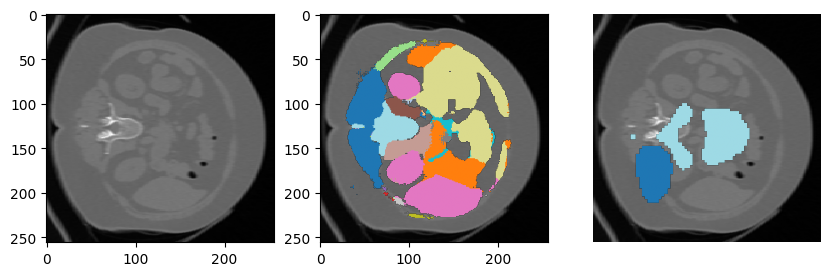

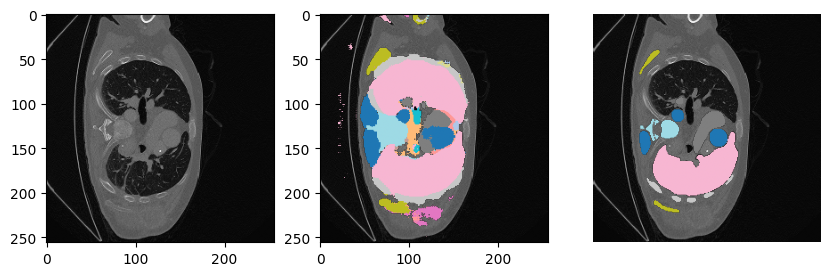

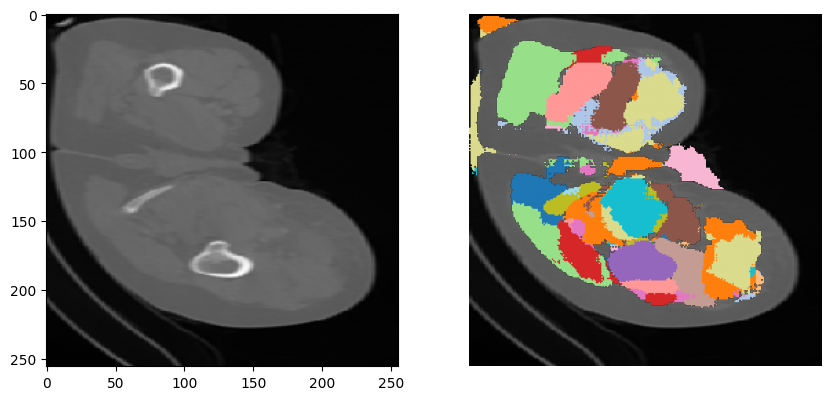

In [64]:
plt_pred(test_model, 1, "train")
plt_pred(test_model, 6, "val")
plt_pred(test_model, 6, "test")

In [56]:
test_loader = DataLoader(x_test, batch_size=1, shuffle=False)

predictions = []

for image in test_loader :
    image = image.to(device=device)

    output = test_model(image)

    pred = torch.argmax(output, dim=1)
    predictions.append(pred.cpu().numpy())

predictions = np.array(predictions)
print("n unique values:", len(np.unique(predictions)))
df = pd.DataFrame(predictions.reshape((predictions.shape[0], -1))).T

df.index = [f"Pixel {i}" for i in df.index]

df.columns = [f"{col}.png" for col in df.columns]

df.to_csv("submission.csv")

KeyboardInterrupt: 